## EEG data in the dying human brain  





DATASET : 

- Original paper :  Surge of neurophysiological coupling and connectivity of gamma oscillations in the dying human brain (Xu et al.,2023) https://www.pnas.org/doi/abs/10.1073/pnas.2216268120

- Data available here : https://zenodo.org/records/7803212#.ZC3Cb-zML0q

- Supporting information available here : https://universityofsussex-my.sharepoint.com/:b:/r/personal/rb666_sussex_ac_uk/Documents/Projects/LZ%20NDE/Supplementary%20pnas.2216268120.sapp.pdf?csf=1&web=1&e=TY5ZjD

---------------------------------------------------------------------

@Code : Romy Beauté\
@Contact : r.beaut@sussex.ac.uk\
@Date : 22/02/24\
@Last modified : 28/02/24

In [4]:
# %matplotlib widget
%matplotlib inline


import matplotlib
import matplotlib.pyplot as plt
import mne
import numpy as np
import os
import sys

###################### Hand made libraries ######################



EEG files in /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed : ['Pt4_S2-end_end_preprocessed_epo.fif', 'Pt2_S1_baseline_preprocessed_epo.fif', 'Pt4_S1_baseline_preprocessed_eeg.fif', 'Pt1_S2-end_end_preprocessed_epo.fif', 'Pt3_S1_baseline_preprocessed_eeg.fif', 'Pt3_S2-end_end_preprocessed_eeg.fif', 'Pt1_S1_baseline_preprocessed_epo.fif', 'Pt2_S2-end_end_preprocessed_epo.fif', 'Pt3_S1_baseline_preprocessed_epo.fif', 'Pt3_S2-end_end_preprocessed_epo.fif', 'Pt1_S1_baseline_preprocessed_eeg.fif', 'Pt2_S2-end_end_preprocessed_eeg.fif', 'Pt4_S2-end_end_preprocessed_eeg.fif', 'Pt2_S1_baseline_preprocessed_eeg.fif', 'Pt1_S2-end_end_preprocessed_eeg.fif', 'Pt4_S1_baseline_preprocessed_epo.fif']
Reading /Users/rb666/projects/DATA/EEG/Gang_2023/preprocessed/Pt1_S1_baseline_preprocessed_epo.fif ...
Isotrak not found
    Found the data of interest:
        t =       0.00 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
59 matching events found
No baseline 

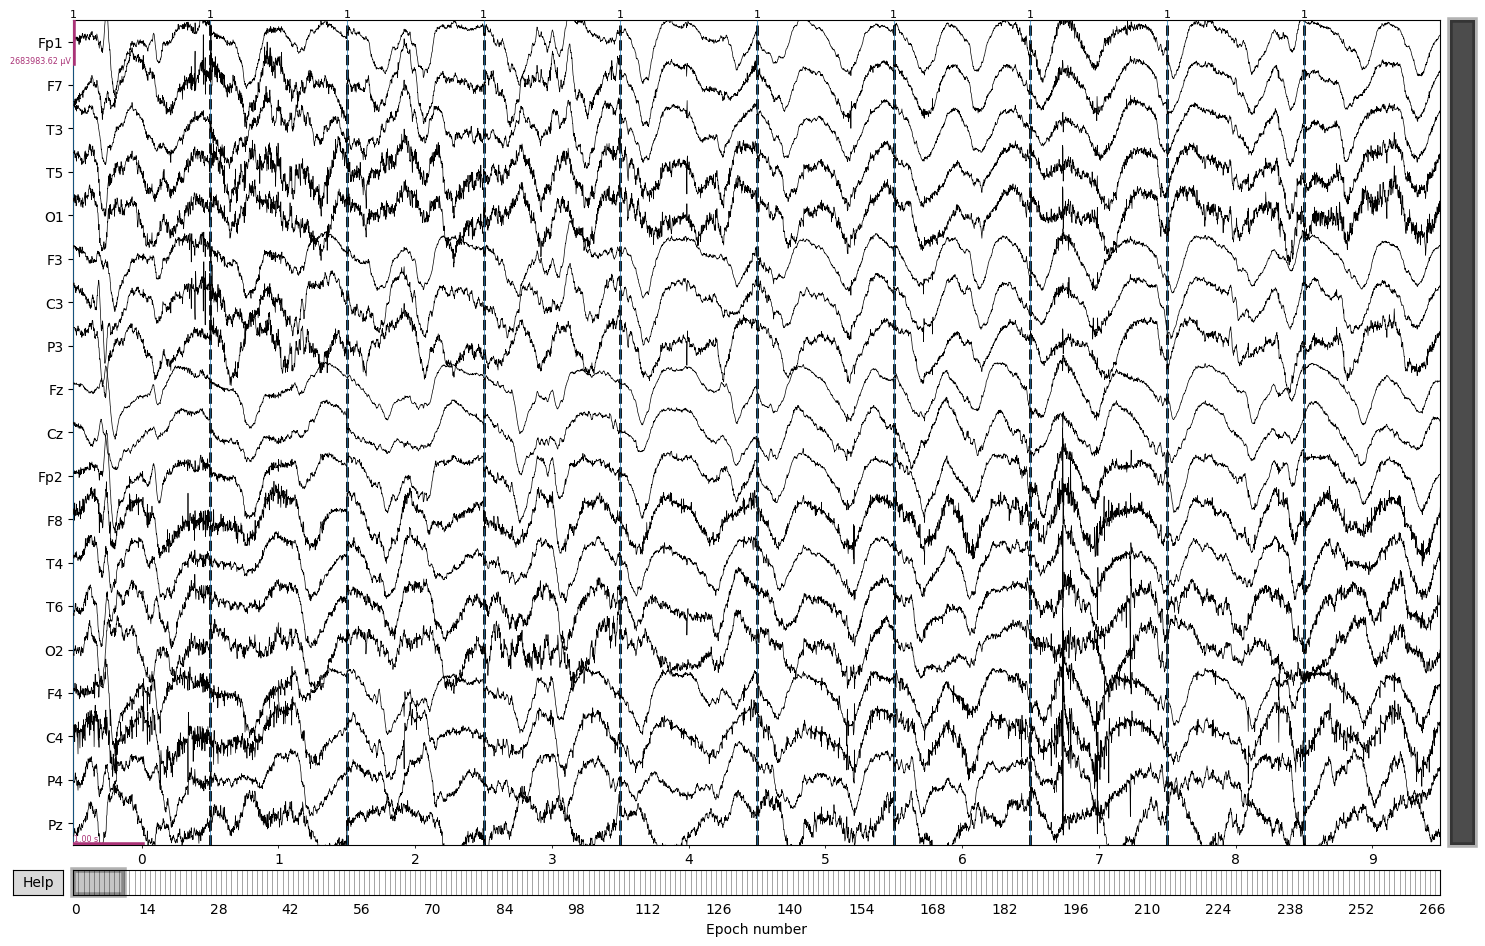

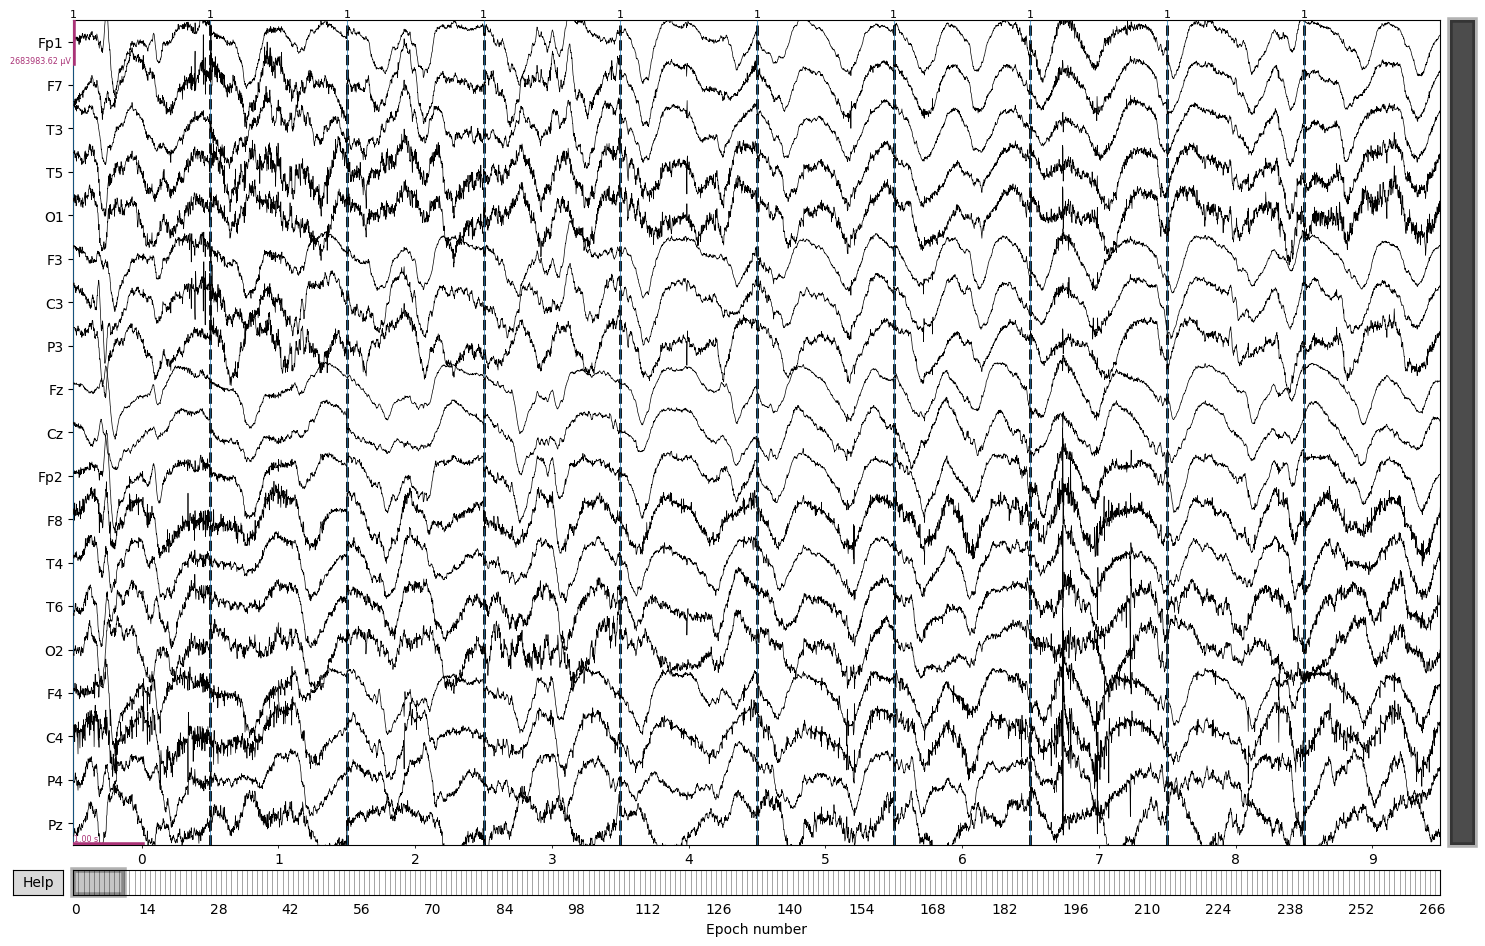

In [5]:
# #####################  SELECT DATASET ####################################################################
DATASET_name = "Gang_2023"
patient = 1

############################################################################################################

DATASET_path = os.path.expanduser(f"~/projects/DATA/EEG/{DATASET_name}/preprocessed") #preprocessed data path

EEG_files = os.listdir(DATASET_path)
print(f"EEG files in {DATASET_path} : {[file for file in EEG_files if file.endswith('.fif')]}")


#Get preprocessed baseline eeg and epochs
EEG_file_baseline = 'Pt{}_S1_baseline_preprocessed_eeg.fif'.format(patient)
epoch_file_baseline = 'Pt{}_S1_baseline_preprocessed_epo.fif'.format(patient)
epoch_baseline = mne.read_epochs(os.path.join(DATASET_path,epoch_file_baseline))
print(f"{len(epoch_baseline)} epochs in baseline stage")

#Get preprocessed end eeg and epochs
EEG_file_end = 'Pt{}_S2-end_end_preprocessed_eeg.fif'.format(patient)
epoch_file_end = 'Pt{}_S2-end_end_preprocessed_epo.fif'.format(patient)
epoch_end = mne.read_epochs(os.path.join(DATASET_path,epoch_file_end))
print(f"{len(epoch_end)} epochs in S2-end stages")

#visualise epochs 
type(epoch_end)
epoch_end.plot(n_epochs=10,events=True,scalings='auto')


## Computes LZc values in three different ways:
### 1. LZc values for each channel and each epoch :

Calculates LZc individually for every epoch within each channel. Results in detailed map of LZc values where each channel's temporal dynamics are preserved across epochs.
- Temporal Analysis: It is primarily used for temporal analysis since it tracks how the complexity of the EEG signal changes over time in each channel.
- Spatial Analysis: It also provides spatial information by showing how complexity varies across different channels at each time point.

### 2. LZc values averaged across all channels for each epoch:

Avg the LZc values across all channels for each epoch. Get single LZc value for every epoch, representing the average complexity across all channels at that specific time point.
- Temporal Analysis: Suitable for temporal analysis as it gives a global view of the brain's complexity at each epoch, though it averages out the spatial differences


### 3. LZc values averaged across all epochs for each channel.

LZc values averaged across all epochs for each channel. Results in a single LZc value per channel, reflecting the average complexity of that channel over the entire recording period
- Spatial Analysis: Mainly used for spatial analysis. Helps understand the avg complexity of each channel, highlighting differences or similarities in complexity across different brain regions

In [6]:
from helpers.univariate_LZc import compute_comprehensive_LZc,normalize_LZc,compute_LZc_for_all_channels,compute_LZc_for_all_channels_and_epochs,plot_LZc_time_series

LZc_baseline = compute_comprehensive_LZc(epoch_baseline) #compute the Lempel-Ziv complexity (LZc) for EEG data across all channels and epochs for stage S1
LZc_end = compute_comprehensive_LZc(epoch_end) #compute the Lempel-Ziv complexity (LZc) for EEG data across all channels and epochs for stage S2 to the end of the recording


print(LZc_baseline.keys())

LZc_baseline_temporal = LZc_baseline['LZc_avg_across_channels_per_epoch']
LZc_end_temporal = LZc_end['LZc_avg_across_channels_per_epoch']

print(len(LZc_baseline_temporal)) #check (should have length corresponding to number of baseline epochs)
print(len(LZc_end_temporal)) #check (should have length corresponding to number of end epochs)



dict_keys(['LZc_per_channel_and_epoch', 'LZc_avg_across_channels_per_epoch', 'LZc_avg_across_epochs_per_channel'])
59
268


## Shuffle LZ and Normalize

### Shuffling LZ Complexity Values:

- Objective: shuffle to create a baseline or reference distribution of LZ complexity values under the assumption that any structure in the EEG signal is due to chance (akin to permutation test)
- Method: shuffle the binarised EEG data multiple times (e.g., 1000 times) and recalculating LZc for each shuffled version to create a distribution of LZc values that would be expected if the EEG data were random

### Normalizing Using Shuffled LZ Values:

- Objective: Normalization against this shuffled baseline helps in assessing the significance of the observed LZc values. Allows to understand whether the complexity observed in the actual EEG data is significantly different from what might be expected in random data.
- Method: done by comparing the actual LZc values to the shuffled LZc distribution and calculating measure z-score 

In [7]:
normalized_LZc_baseline = normalize_LZc(epoch_baseline)
normalized_LZc_end = normalize_LZc(epoch_end)

### Outlier detection of LZ measures 

Outliers using Z-score in S1: []
Outliers using Z-score in End: []
Outliers using IQR in S1: [0.481606082976136, 0.4733891071528465, 0.48754056551517844]
Outliers using IQR in End: []


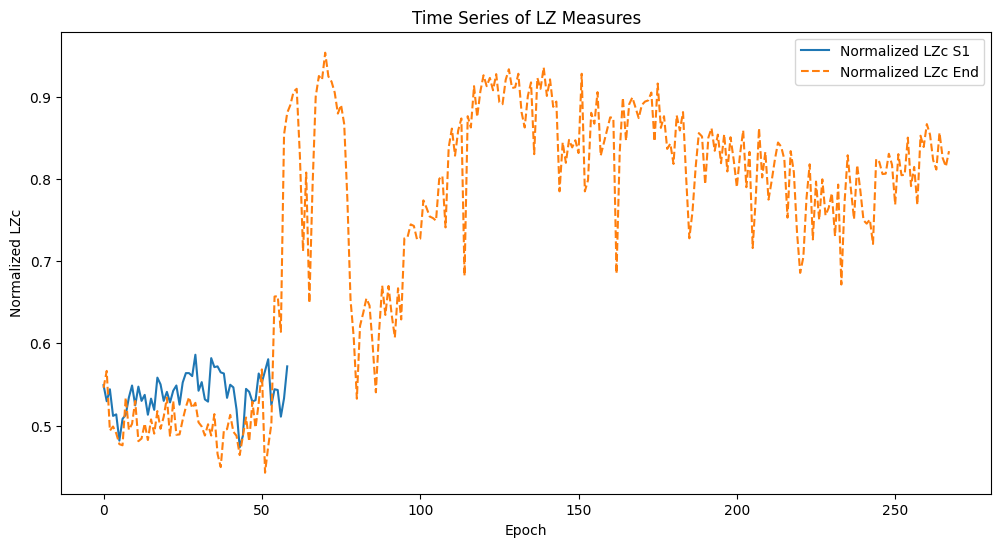

In [14]:
# Function to detect outliers using Z-score
def detect_outliers_z_score(data):
    threshold = 3
    mean = np.mean(data)
    std = np.std(data)
    outliers = []
    for i in data:
        z_score = (i - mean) / std
        if np.abs(z_score) > threshold:
            outliers.append(i)
    return outliers


# Function to detect outliers using IQR
def detect_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = [i for i in data if i < lower_bound or i > upper_bound]
    return outliers



# Detect outliers using Z-score
outliers_z_score_S1 = detect_outliers_z_score(normalized_LZc_baseline)
outliers_z_score_end = detect_outliers_z_score(normalized_LZc_end)

# Detect outliers using IQR
outliers_iqr_S1 = detect_outliers_iqr(normalized_LZc_baseline)
outliers_iqr_end = detect_outliers_iqr(normalized_LZc_end)

print("Outliers using Z-score in S1:", outliers_z_score_S1)
print("Outliers using Z-score in End:", outliers_z_score_end)
print("Outliers using IQR in S1:", outliers_iqr_S1)
print("Outliers using IQR in End:", outliers_iqr_end)

# # Visualization using Box Plot
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# plt.boxplot(normalized_LZc_baseline, vert=False)
# plt.title('Box Plot of Normalized LZc S1')
# plt.subplot(1, 2, 2)
# plt.boxplot(normalized_LZc_end, vert=False)
# plt.title('Box Plot of Normalized LZc End')
# plt.show()






### Temporal visualisation of LZc

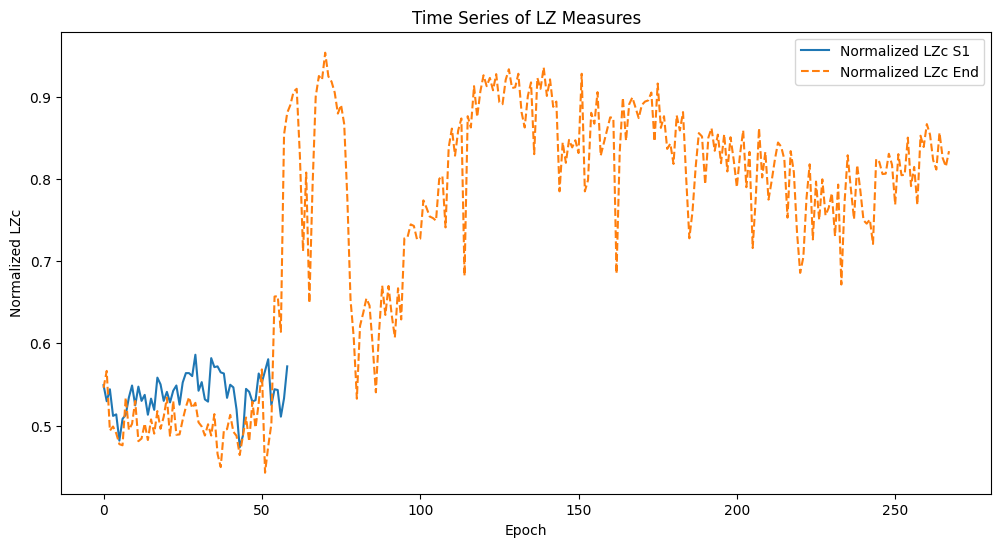

In [15]:
# Plotting the time series of LZ measures
plt.figure(figsize=(12, 6))
plt.plot(normalized_LZc_baseline, label='Normalized LZc S1')
plt.plot(normalized_LZc_end, label='Normalized LZc End', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Normalized LZc')
plt.title('Time Series of LZ Measures')
plt.legend()
plt.show()

In [17]:
epoch_end.annotations

<Annotations | 10 segments: 108s (1), 123s (1), 16s (1), 18s (2), 45s (1), ...>

### Spatial visualisation of LZ

Channel Fp1 has an average LZc of 84.78
Channel F7 has an average LZc of 82.43
Channel T3 has an average LZc of 87.90
Channel T5 has an average LZc of 91.89
Channel O1 has an average LZc of 86.36
Channel F3 has an average LZc of 85.12
Channel C3 has an average LZc of 83.04
Channel P3 has an average LZc of 87.75
Channel Fz has an average LZc of 84.42
Channel Cz has an average LZc of 80.62
Channel Fp2 has an average LZc of 82.65
Channel F8 has an average LZc of 84.33
Channel T4 has an average LZc of 90.57
Channel T6 has an average LZc of 93.44
Channel O2 has an average LZc of 87.30
Channel F4 has an average LZc of 83.92
Channel C4 has an average LZc of 86.71
Channel P4 has an average LZc of 89.34
Channel Pz has an average LZc of 87.49


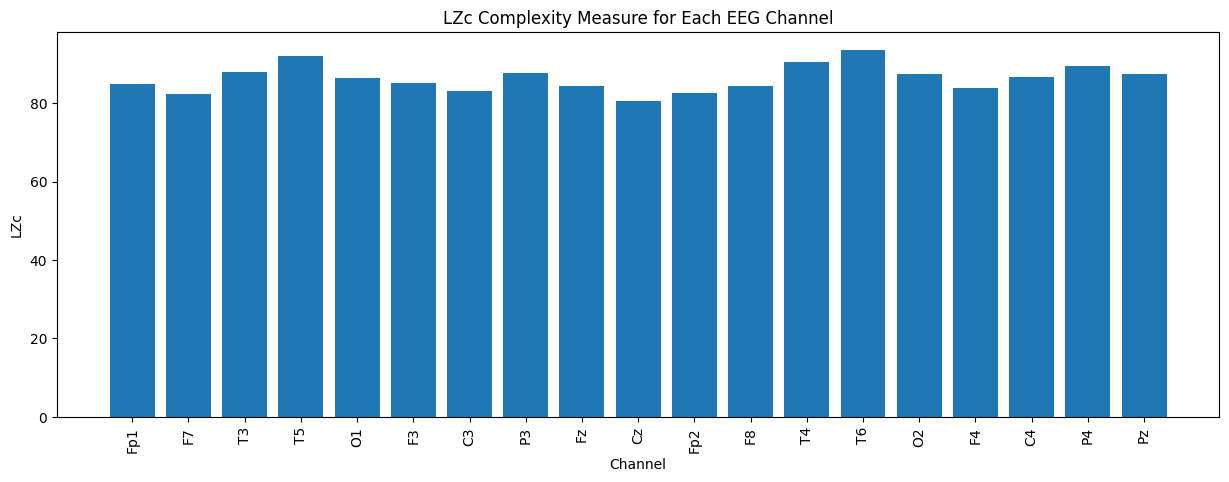

In [12]:
#  LZc values for each channel
LZc_results = compute_LZc_for_all_channels(epoch_end)
for channel, LZc in LZc_results.items():
    print(f"Channel {channel} has an average LZc of {LZc:.2f}")


# Plot LZc values for each channel
channels = list(LZc_results.keys())
values = list(LZc_results.values())

plt.figure(figsize=(15, 5))
plt.bar(channels, values)
plt.xlabel('Channel')
plt.ylabel('LZc')
plt.title('LZc Complexity Measure for Each EEG Channel')
plt.xticks(rotation=90)  
plt.show()

### Spatiotemporal visualisation of LZc

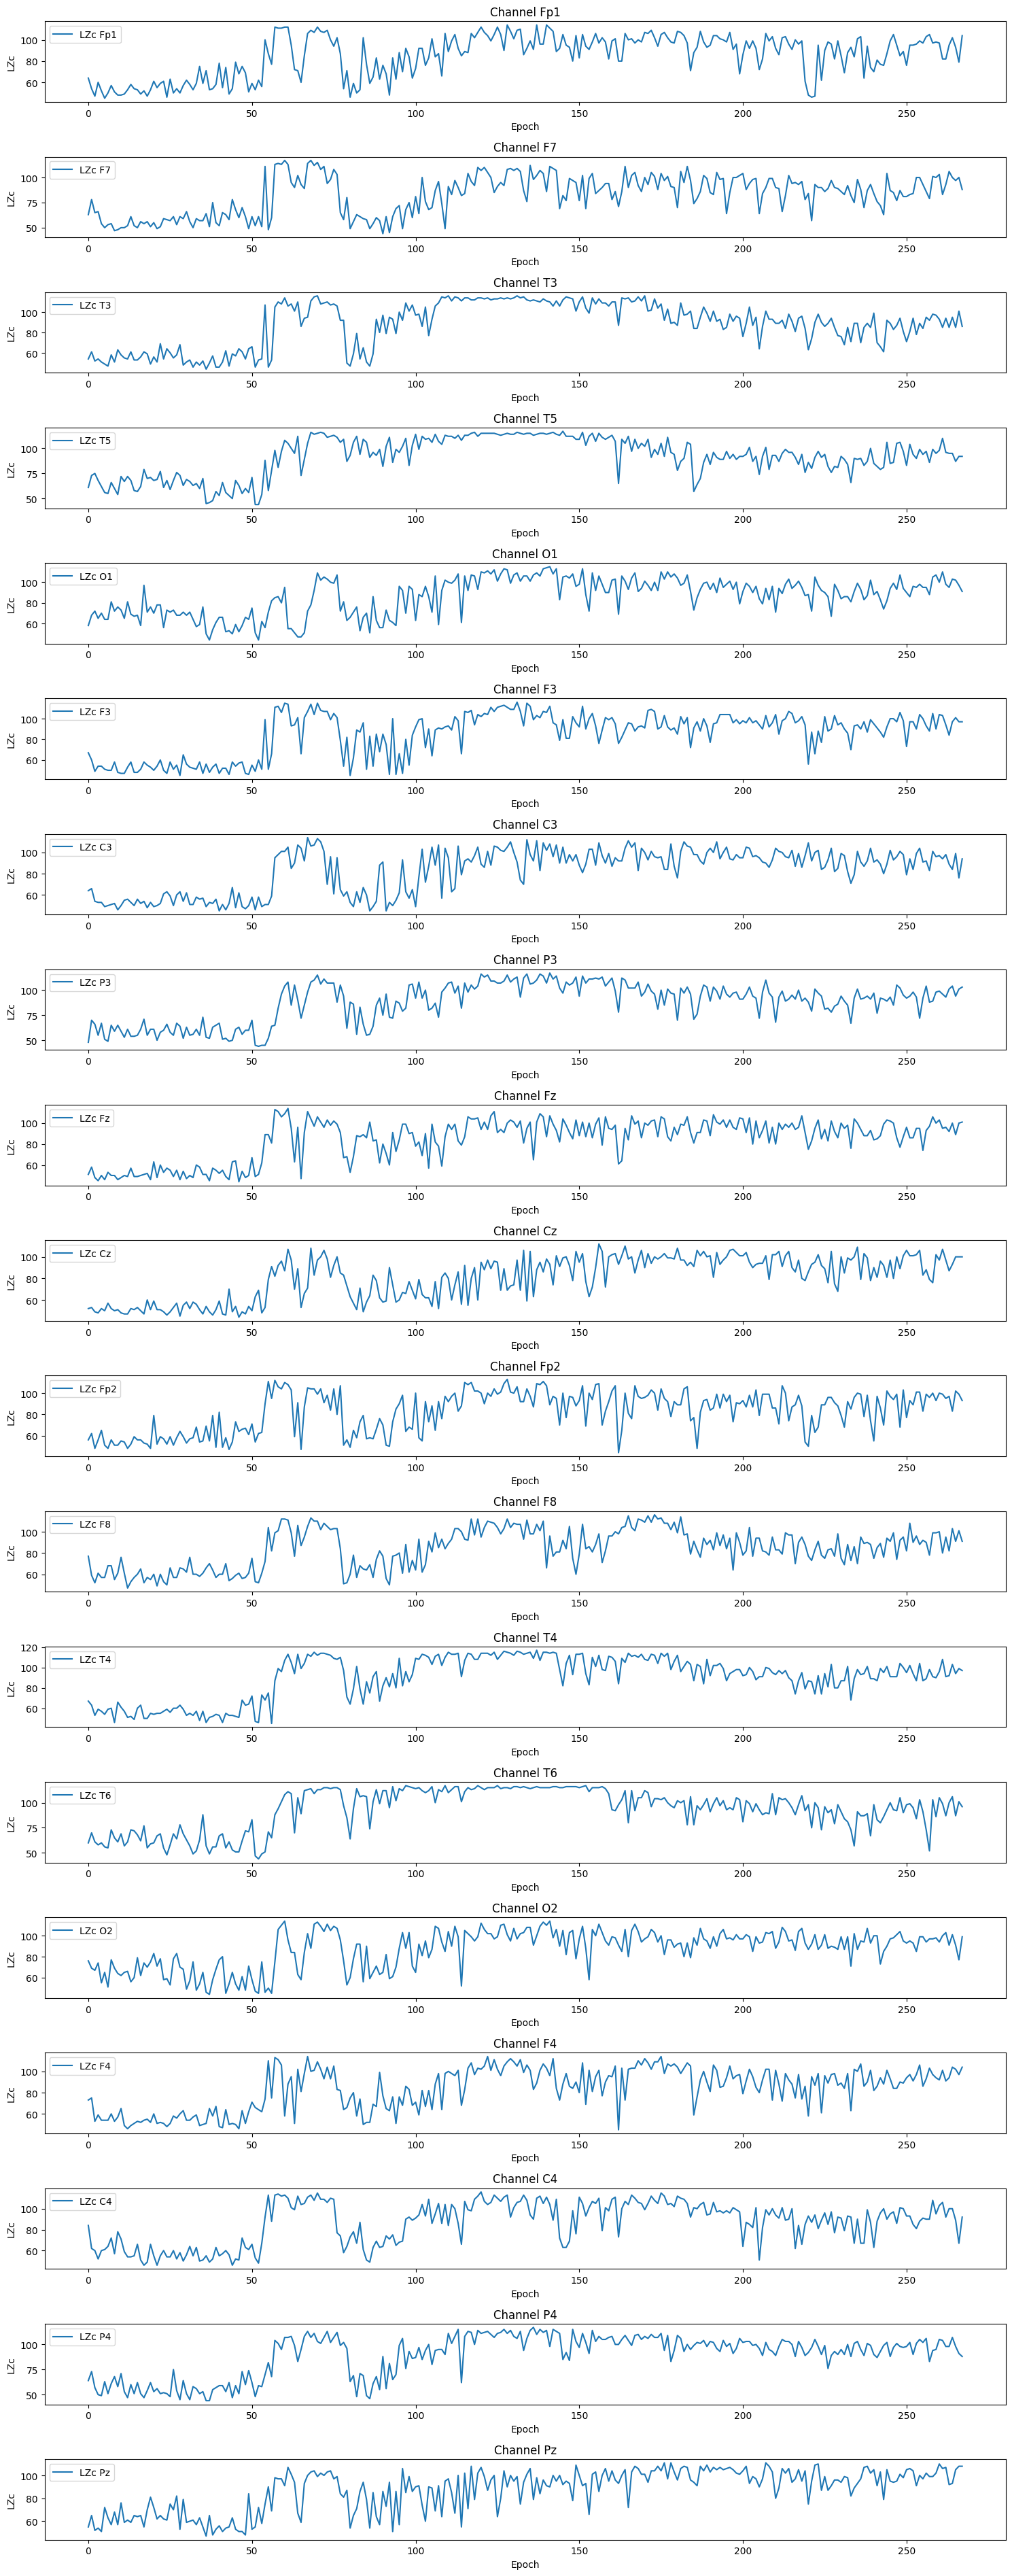

In [13]:
# Compute LZc for all channels and epochs
LZc_all_epochs = compute_LZc_for_all_channels_and_epochs(epoch_end)

# Plot the LZc time series
plot_LZc_time_series(LZc_all_epochs)

### Topographic maps of LZc

In [10]:
# montage = mne.channels.make_standard_montage('standard_1020')

# def plot_topomap(LZc_values, epochs_info):
#     # Assume LZc_values is a dictionary with channel names as keys and LZc values as lists
#     average_LZc = {ch: np.mean(values) for ch, values in LZc_values.items()}
#     # Create an Info object needed for topographic plotting
#     info = mne.create_info(ch_names=list(average_LZc.keys()), sfreq=epochs_info['sfreq'], ch_types='eeg')
#     info.set_montage(montage)
    
#     # Create data array for the LZc values
#     data_array = np.array([average_LZc[ch] for ch in info.ch_names])
    
#     # create Evoked object
#     evoked = mne.EvokedArray(data_array[:, np.newaxis], info, tmin=0)
    
#     # Plot topomap
#     evoked.plot_topomap(times=[0], scalings=1, time_unit='s', size=3)

# #call the function with the LZc values dictionary and the info from your epochs
# plot_topomap(LZc_all_epochs, epoch_end.info)
